---
title: Uczenie maszynowe. Lista 3
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.17.3
  kernelspec:
    display_name: Python 3 (ipykernel)
    language: python
    name: python3
---

# Laboratorium 3

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
heart_df = pd.read_csv("./Heart_disease_cleveland_new.csv")

[Źródło](https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland)
Age: Patients Age in years (Numeric)
Sex: Gender (Male : 1; Female : 0) (Nominal)
cp: Type of chest pain experienced by patient. This term categorized into 4 category.
0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
trestbps: patient's level of blood pressure at resting mode in mm/HG (Numerical)
chol: Serum cholesterol in mg/dl (Numeric)
fbs: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)
restecg: Result of electrocardiogram while at rest are represented in 3 distinct values
0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of >
0.05 mV) 2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
thalach: Maximum heart rate achieved (Numeric)
exang: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
oldpeak: Exercise induced ST-depression in relative with the state of rest (Numeric)
slope: ST segment measured in terms of slope during peak exercise
0: up sloping; 1: flat; 2: down sloping(Nominal)
ca: The number of major vessels (0–3)(nominal)
thal: A blood disorder called thalassemia
0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)
target: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.

In [3]:
heart_df.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
5,56,1,1,120,236,0,0,178,0,0.8,0,0,1,0
6,62,0,3,140,268,0,2,160,0,3.6,2,2,1,1
7,57,0,3,120,354,0,0,163,1,0.6,0,0,1,0
8,63,1,3,130,254,0,2,147,0,1.4,1,1,3,1
9,53,1,3,140,203,1,2,155,1,3.1,2,0,3,1


In [4]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
heart_df.select_dtypes(include="number").describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


Text(0.5, 1.0, 'Zbalansowanie klasy docelowej')

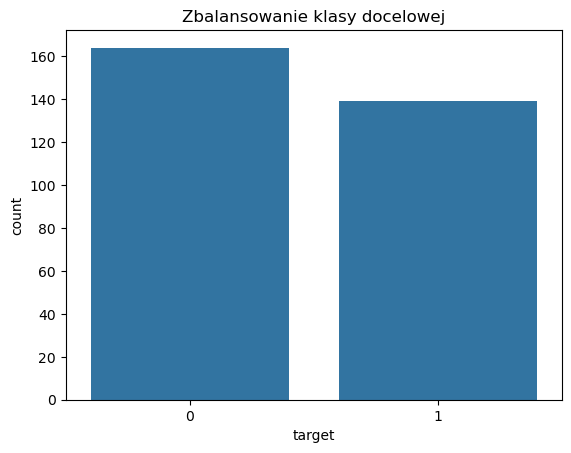

In [15]:
sns.countplot(heart_df, x="target")
plt.title("Zbalansowanie klasy docelowej")

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

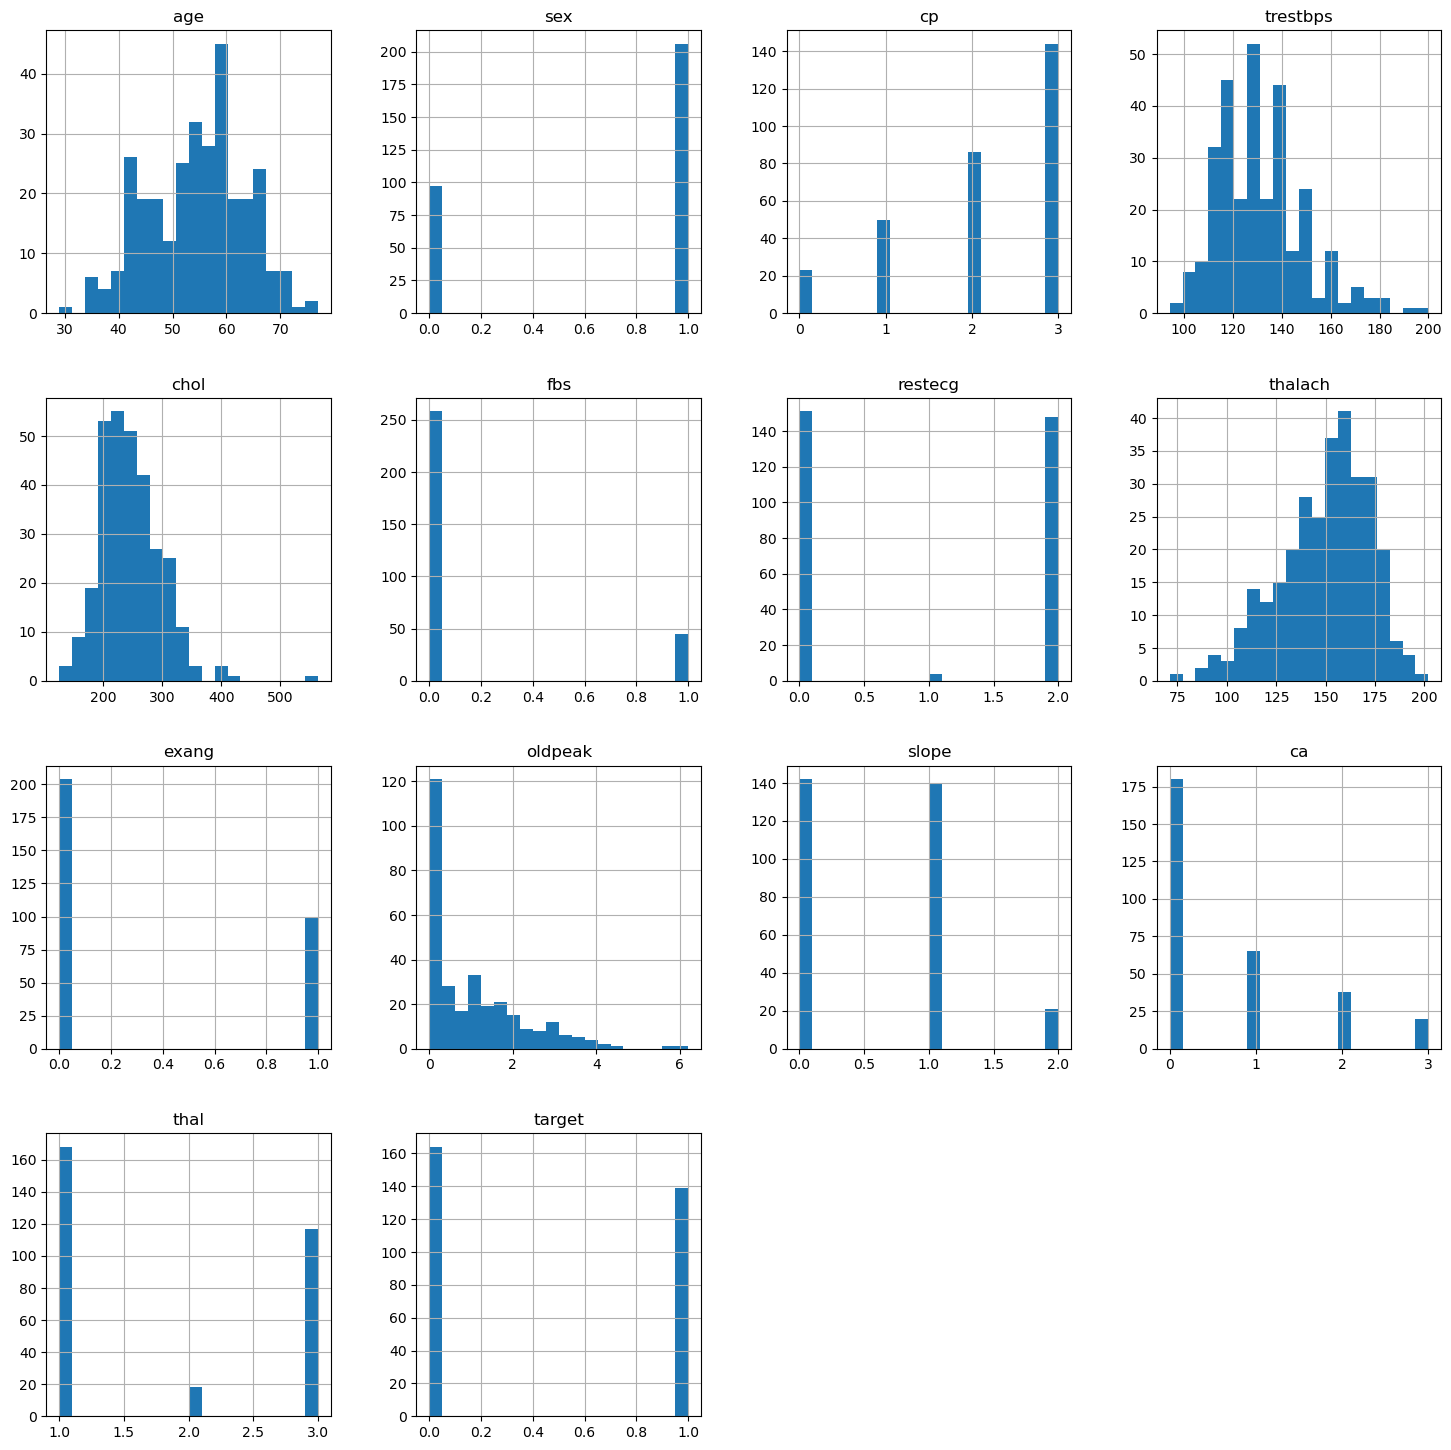

In [18]:
heart_df.hist(figsize=(18,18), bins=20)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline

X = heart_df.drop("target", axis=1)
y = heart_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=100)

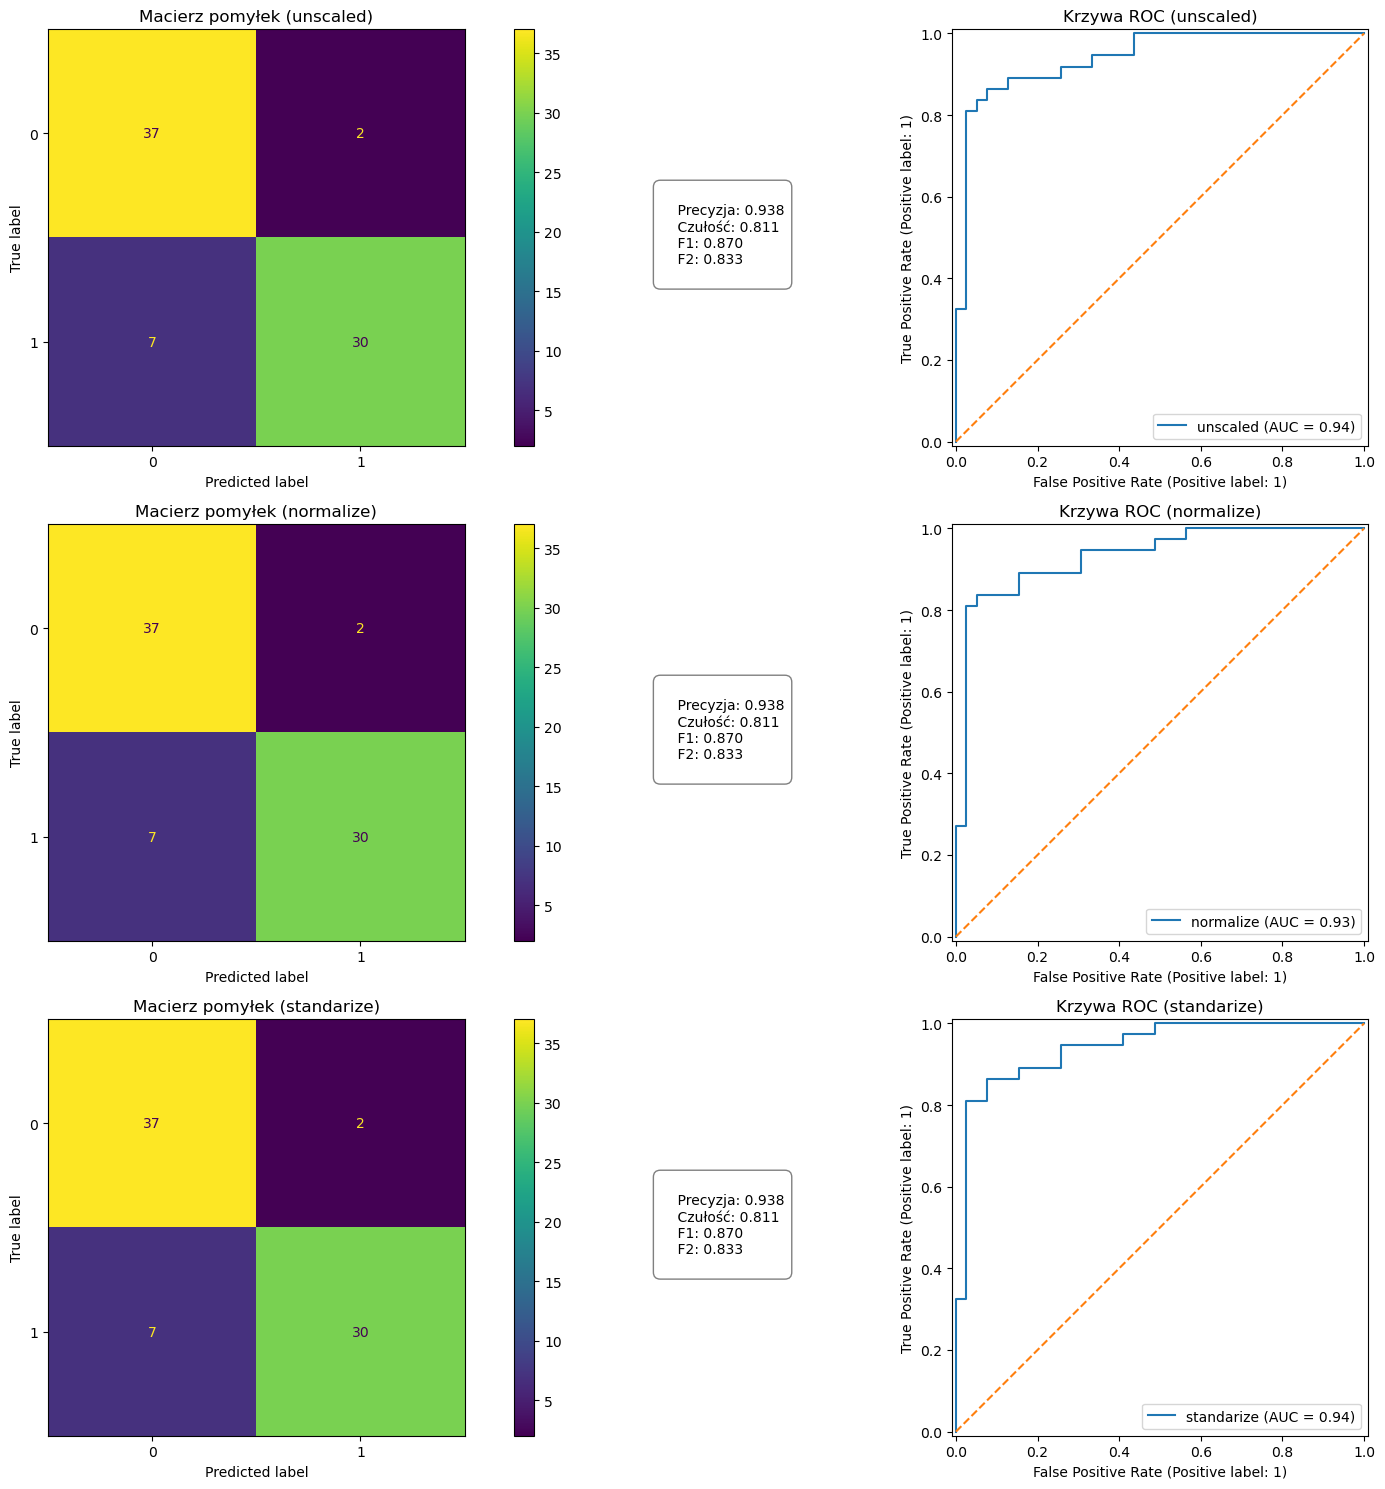

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, make_scorer, fbeta_score

models = {
    "unscaled": LogisticRegression(random_state=100, max_iter=10**4),
    "normalize": Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", LogisticRegression(random_state=100))
    ]),
    "standarize": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=100))
    ])
}

fig, axes = plt.subplots(3, 2, figsize=(20, 15))

for (name, model), ax in zip(models.items(), axes):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    cm_disp.plot(ax=ax[0])
    ax[0].set_title(f"Macierz pomyłek ({name})")

    roc = RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax[1])
    ax[1].plot([0, 1], [0, 1], linestyle="--", label="losowe zgadywanie")
    ax[1].set_title(f"Krzywa ROC ({name})")

    tn, fp, fn, tp = cm.ravel()

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = (2 * precision * recall) / (precision + recall)
    f2 = fbeta_score(y_test, y_pred, beta=2)

    metrics_str = f"""
    Precyzja: {precision:.3f}
    Czułość: {recall:.3f}
    F1: {f1:.3f}
    F2: {f2:.3f}
    """

    ax[1].text(
        -0.70,
        0.40,
        metrics_str,
        transform=ax[1].transAxes,
        bbox = {"boxstyle": "round,pad=0.5", "edgecolor":"gray", "facecolor":"white"}
    )

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Liczba iteracji')

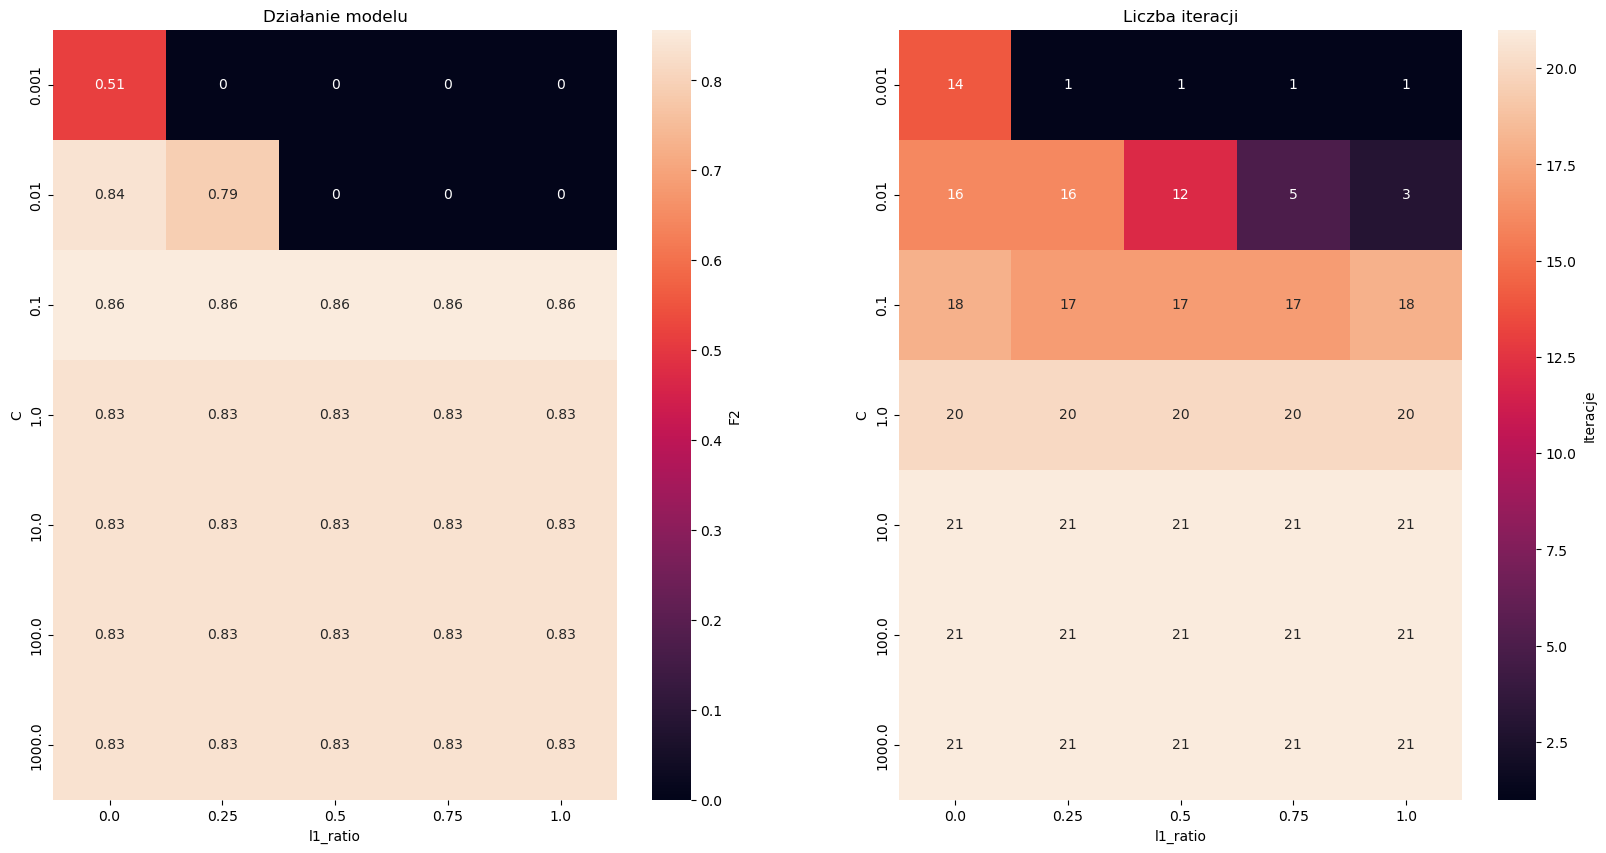

In [13]:
res = []

for C in [10**x for x in range(-3, 4)]:
    for l1_ratio in [x/100 for x in range(0, 101, 25)]:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                C=C,
                l1_ratio=l1_ratio,
                random_state=100,
                max_iter=10000
            ))
        ])

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
        tn, fp, fn, tp = cm.ravel()

        precision = tp / (tp + fp) if tp + fp > 0 else 0
        recall = tp / (tp + fn) if tp + fn > 0 else 0
        f2 = fbeta_score(y_test, y_pred, beta=2)

        res.append({
            "C": C,
            "l1_ratio": l1_ratio,
            "precision": precision,
            "recall": recall,
            "f2": f2,
            "iters": model.named_steps["clf"].n_iter_[0],
        })


fig, axes = plt.subplots(1, 2, figsize=(20,10))
axes = axes.flatten()

pivot_df = pd.DataFrame(res).pivot(index="C", columns="l1_ratio", values="f2")
sns.heatmap(
    pivot_df,
    annot=True,
    cbar_kws={"label": "F2"},
    ax=axes[0]
)
axes[0].set_title("Działanie modelu")

iter_pivot_df = pd.DataFrame(res).pivot(index="C", columns="l1_ratio", values="iters")
sns.heatmap(
    iter_pivot_df,
    annot=True,
    cbar_kws={"label": "Iteracje"},
    ax=axes[1]
)
axes[1].set_title("Liczba iteracji")

In [14]:
from itertools import product
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=100))
])

res_cv = []

f2_scorer = make_scorer(fbeta_score, beta=2)

for fold, stratify in product([2, 5, 10], [True, False]):
    if stratify:
        cv = StratifiedKFold(n_splits=fold, shuffle=True, random_state=100)
    else:
        cv = KFold(n_splits=fold, shuffle=True, random_state=100)

    scores = cross_val_score(model, X, y, cv=cv, scoring=f2_scorer)

    mean_scores = np.mean(scores)
    std_scores = np.std(scores)
    res_cv.append({
        "stratyfikacja": "Tak" if stratify else "Nie",
        "rozmiar": fold,
        "srednia": mean_scores,
        "zmiennosc": std_scores
    })

res_cv_df = pd.DataFrame(res_cv)
res_cv_df.head(10)

,stratyfikacja,rozmiar,srednia,zmiennosc
0,Tak,2,0.748525,0.036359
1,Nie,2,0.774532,0.026029
2,Tak,5,0.794744,0.127990
3,Nie,5,0.791207,0.036565
4,Tak,10,0.789864,0.132617
5,Nie,10,0.791027,0.065231
